1.Import Libraries

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)


TensorFlow: 2.20.0
Keras: 3.13.2


2. Load Dataset

In [5]:
df= pd.read_csv("breast_cancer_data.csv")
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nData types:")
display(df.dtypes.value_counts())

Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing values:


,0
Unnamed: 32,569
id,0
diagnosis,0
texture_mean,0
radius_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
perimeter_mean,0
concave points_mean,0



Data types:


,count
float64,31
int64,1
object,1


3. Data Preprocessing

In [7]:
drop_columns = [col for col in ["id", "Unnamed: 32"] if col in df.columns]
df = df.drop(columns=drop_columns)

# Encode diagnosis: Benign = 0, Malignant = 1
if df["diagnosis"].dtype == "object":
    df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

df["diagnosis"] = df["diagnosis"].astype(int)

print("Shape after cleaning:", df.shape)
display(df.head())


Shape after cleaning: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Class distribution:
Benign: 357
Malignant: 212


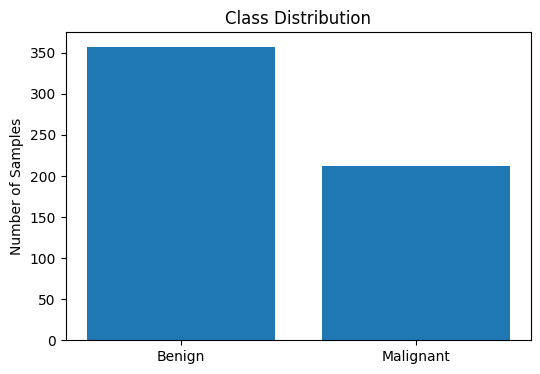

In [8]:
class_counts = df["diagnosis"].value_counts().sort_index()
class_labels = ["Benign", "Malignant"]

print("Class distribution:")
for label, count in zip(class_labels, class_counts):
    print(f"{label}: {count}")

plt.figure(figsize=(6, 4))
plt.bar(class_labels, class_counts.values)
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.show()

In [9]:
display(df.describe().T.head(10))

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.00000,0.00000,0.00000,1.0000,1.0000
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.1304,0.3454
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.1307,0.4268
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.0740,0.2012
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.1957,0.3040


3. Train / Validation / Test Split

A stratified split is used so the class distribution remains similar across the three subset

In [10]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# 60% train, 20% validation, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=SEED
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Training: (341, 30)
Validation: (114, 30)
Test: (114, 30)


4. Feature Scaling

The scaler is fitted **only on the training set** to prevent information leakage.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)


Scaled training shape: (341, 30)


5. Build the Keras Neural Network

In [12]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(80, activation="relu"),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         3,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,261 (43.99 KB)

 Trainable params: 11,261 (43.99 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7771 - loss: 0.5281 - val_accuracy: 0.9298 - val_loss: 0.3343
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9267 - loss: 0.2527 - val_accuracy: 0.9474 - val_loss: 0.2100
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9413 - loss: 0.1639 - val_accuracy: 0.9737 - val_loss: 0.1511
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9619 - loss: 0.1204 - val_accuracy: 0.9825 - val_loss: 0.1190
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9765 - loss: 0.0950 - val_accuracy: 0.9649 - val_loss: 0.1025
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9824 - loss: 0.0800 - val_accuracy: 0.9649 - val_loss: 0.0933
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9824 - loss: 0.0700 - val_accuracy: 0.9649 - val_loss: 0.0873
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9824 - loss: 0.0625 - val_accuracy: 0.

6. Training Performance

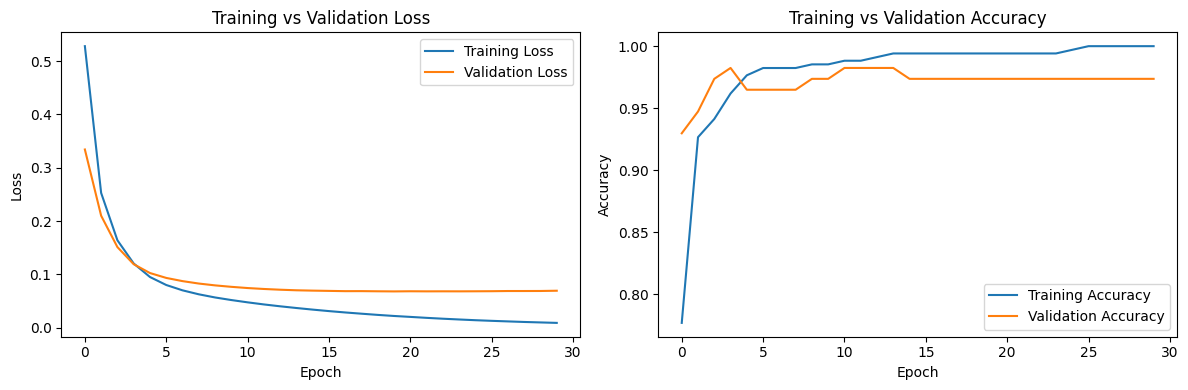

In [14]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


7. Model Evaluation

In [15]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled, y_test, verbose=0
)

y_prob = model.predict(X_test_scaled, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "Test Loss": test_loss,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_prob),
}

display(pd.DataFrame(metrics.items(), columns=["Metric", "Value"]))

,Metric,Value
0,Test Loss,0.095753
1,Accuracy,0.964912
2,Precision,0.975000
3,Recall,0.928571
4,F1 Score,0.951220
5,ROC AUC,0.992725


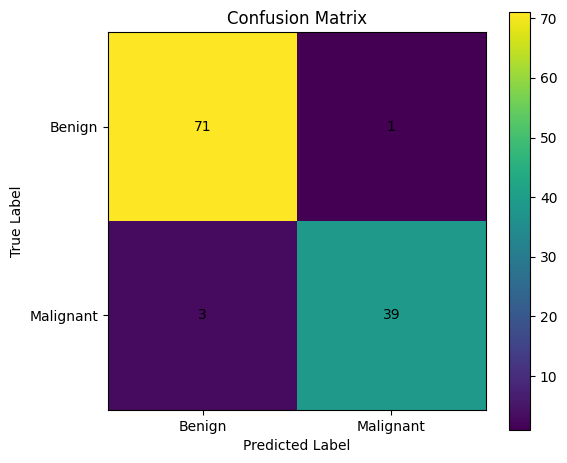

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.yticks([0, 1], ["Benign", "Malignant"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

8. Sample Predictions

The model outputs a probability between 0 and 1. A threshold of **0.5** is used for the binary prediction in this project.

In [17]:
results = X_test.copy()
results["Actual"] = y_test.values
results["Malignant_Probability"] = y_prob
results["Predicted"] = y_pred

display(results[["Actual", "Malignant_Probability", "Predicted"]].head(10))

,Actual,Malignant_Probability,Predicted
120,0,0.000034,0
250,1,1.000000,1
375,0,0.013166,0
99,1,0.854708,1
455,0,0.373896,0
318,0,0.000019,0
39,1,0.976668,1
371,0,0.000156,0
98,0,0.000061,0
502,0,0.006522,0
